In [1]:
import torch
import importlib
import torch.nn as nn
import torch.optim as optim
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, random_split
import os
from pytorch_msssim import ssim
from torchmetrics.image import PeakSignalNoiseRatio
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device('mps' if  torch.backends.mps.is_available() else 'cpu')
print(device)

mps


In [3]:
from base import load_pkl, transform_1, transform_3, calc_loss, CustomData, load_data, fineTune, test_func, NoiseImage
from base import augment, test_func_batches, list_images, collect_images, augment_data


psnr_metric = PeakSignalNoiseRatio(data_range=1.0)
psnr_metric = psnr_metric.to(device)



In [4]:
import base
from base import load_pkl, transform_1, transform_3, calc_loss, CustomData, load_data, fineTune
importlib.reload(base)
psnr_metric = PeakSignalNoiseRatio(data_range=1.0)

In [5]:
from models.pix2pix_model import Pix2PixModel

In [6]:
import argparse

opt = argparse.Namespace(
    # BaseModel.__init__
    isTrain=True,
    checkpoints_dir="./p2pcheckpoints",
    name="pix2pix_sem",
    device=device,
    preprocess="none",

    # BaseModel.setup
    init_type="normal",
    init_gain=0.02,
    continue_train=False,
    load_iter=0,
    epoch="latest",
    verbose=True,

    # Scheduler
    lr_policy="linear",     # linear | step | plateau | cosine
    epoch_count=1,
    n_epochs=100,
    n_epochs_decay=100,
    lr_decay_iters=50,

    # Pix2PixModel.__init__
    input_nc=1,
    output_nc=1,
    ngf=64,
    netG="unet_256",
    norm="batch",
    no_dropout=False,

    ndf=64,
    netD="basic",           # basic | n_layers | pixel
    n_layers_D=3,

    gan_mode="vanilla",
    lr=0.0002,
    beta1=0.5,

    # Pix2PixModel.set_input / backward_G
    direction="AtoB",
    lambda_L1=100.0,
)


In [7]:
p2p_model = Pix2PixModel(opt)
p2p_model.setup(opt)


initialize network with normal
initialize network with normal
---------- Networks initialized -------------
UnetGenerator(
  (model): UnetSkipConnectionBlock(
    (model): Sequential(
      (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): UnetSkipConnectionBlock(
        (model): Sequential(
          (0): LeakyReLU(negative_slope=0.2, inplace=True)
          (1): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
          (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (3): UnetSkipConnectionBlock(
            (model): Sequential(
              (0): LeakyReLU(negative_slope=0.2, inplace=True)
              (1): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
              (2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (3): UnetSkipConnectionBlock(
                (model): Sequential

In [10]:
train_path = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/notebooks/noisy_training.pkl'
test_path = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/notebooks/noisy_testing.pkl'
noisy_training_dataset , noisy_testing_dataset = load_pkl(train_path, test_path)

In [20]:
parent_dir = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/dataset/crop/images'
all_images = collect_images(parent_dir)
np.random.shuffle(all_images)

Total number of images collected: 18577
Shape of the first image: (299, 299, 3)
Type of the first image: <class 'numpy.ndarray'>


In [21]:
train_arrays = all_images[:int(len(all_images)*.70)]
test_arrays = all_images[int(len(all_images)*.70 ):]

In [26]:
noise_obj = NoiseImage()
train_dataset = CustomData(train_arrays, transform= transform_1(256), repeats = 1 , training = True , noise_obj = noise_obj)
test_dataset = CustomData(test_arrays , transform = transform_1(256), repeats = 1, training = False, noise_obj = noise_obj)


In [27]:
train_loader, val_loader, test_loader = load_data(train_dataset, test_dataset, batch_size = 4)

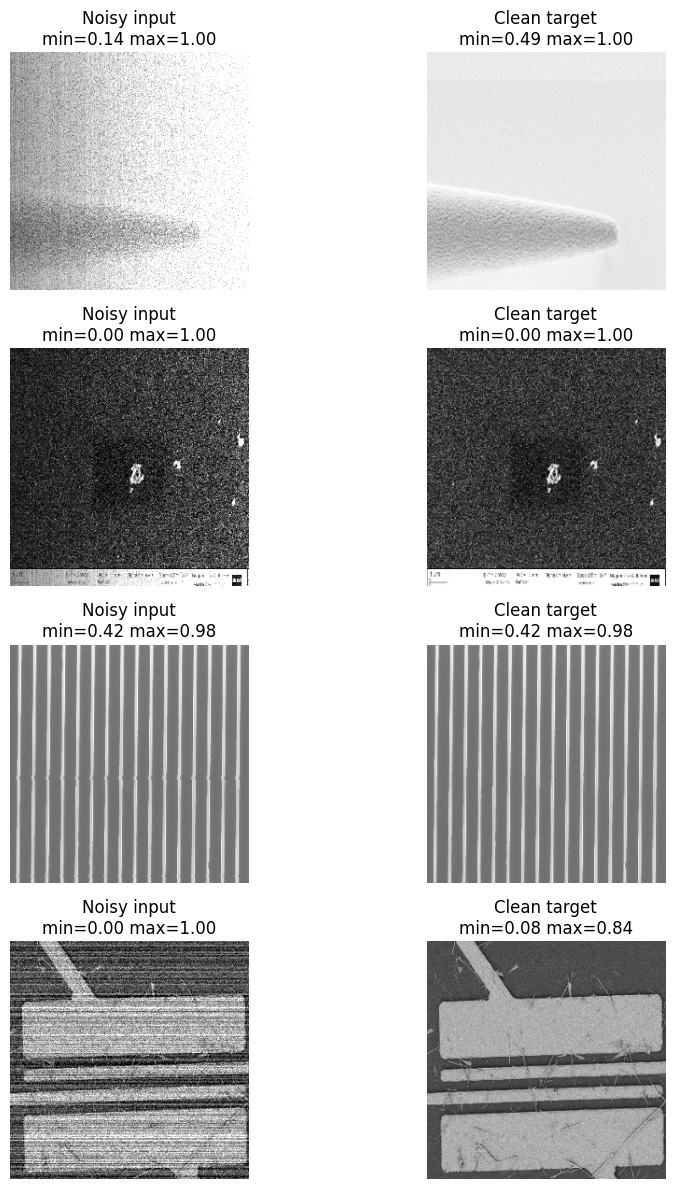

In [28]:
xt, yt = next((iter(train_loader)))
xt, yt = xt.to(device), yt.to(device)


# Move to CPU for plotting
xt_np   = xt.cpu().numpy()
yt_np   = yt.cpu().numpy()





# Plot first 4 images in the batch
n = min(4, xt.shape[0])
fig, axes = plt.subplots(n, 2, figsize=(10, 3*n))
for i in range(n):
    # Handle both (C,H,W) grayscale and RGB
    def to_img(t):
        img = t[i]
        if img.shape[0] == 1:
            return img[0]          # (H, W)
        return img.transpose(1,2,0)  # (H, W, C)

    axes[i, 0].imshow(to_img(xt_np),   cmap='gray', vmin=0, vmax=1)
    axes[i, 0].set_title(f"Noisy input\nmin={xt_np[i].min():.2f} max={xt_np[i].max():.2f}")
    axes[i, 0].axis('off')


    axes[i, 1].imshow(to_img(yt_np),   cmap='gray', vmin=0, vmax=1)
    axes[i, 1].set_title(f"Clean target\nmin={yt_np[i].min():.2f} max={yt_np[i].max():.2f}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [37]:
for epoch in range(10):
    for batch_idx, (x, y) in enumerate(train_loader):
        p2p_model.set_input({'A': x, 'B': y, 'A_paths': '', 'B_paths': ''})
        p2p_model.optimize_parameters()
        losses = p2p_model.get_current_losses()
        if (batch_idx)%10 == 0:
            print(f"Batch {batch_idx}: {losses}")
    print(f"{epoch+1} Done")



    p2p_model.eval()

    val_loss_sum = 0.0
    num_batches = 0

    with torch.no_grad():
        for batch_idx, (x, y) in enumerate(val_loader):
            p2p_model.set_input({'A': x, 'B': y, 'A_paths': '', 'B_paths': ''})
            p2p_model.test()
            losses = p2p_model.get_current_losses()
            if (batch_idx)%10 ==0:
                print(f"Baths {batch_idx} : {losses}")


    if (epoch%2)==0:
        p2p_model.save_networks(epoch)



Batch 0: OrderedDict([('G_GAN', 0.10222197324037552), ('G_L1', 5.2865471839904785), ('D_real', 0.6149415373802185), ('D_fake', 0.4593731164932251)])
Batch 10: OrderedDict([('G_GAN', 1.5890629291534424), ('G_L1', 22.24813461303711), ('D_real', 141.0873260498047), ('D_fake', 0.002791580045595765)])
Batch 20: OrderedDict([('G_GAN', 1.5026051998138428), ('G_L1', 10.10154914855957), ('D_real', 0.5630298256874084), ('D_fake', 1.287401556968689)])
Batch 30: OrderedDict([('G_GAN', 2.6896088123321533), ('G_L1', 9.219751358032227), ('D_real', 0.12903745472431183), ('D_fake', 2.830939769744873)])
Batch 40: OrderedDict([('G_GAN', 3.3590247631073), ('G_L1', 6.422731399536133), ('D_real', 0.5432433485984802), ('D_fake', 1.8799947500228882)])
Batch 50: OrderedDict([('G_GAN', 0.6471388339996338), ('G_L1', 8.422672271728516), ('D_real', 0.9809200167655945), ('D_fake', 0.4225456714630127)])
Batch 60: OrderedDict([('G_GAN', 0.3969545364379883), ('G_L1', 5.514498233795166), ('D_real', 1.2321240901947021),

Batch 10: OrderedDict([('G_GAN', 3.0159342288970947), ('G_L1', 5.0559186935424805), ('D_real', 0.0009034321992658079), ('D_fake', 0.3480606973171234)])


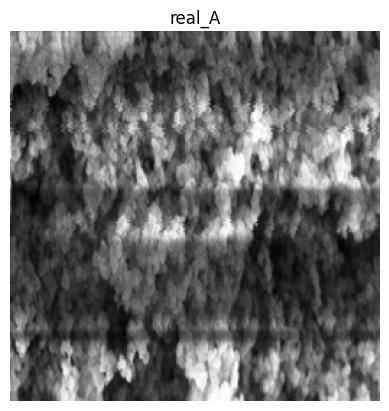

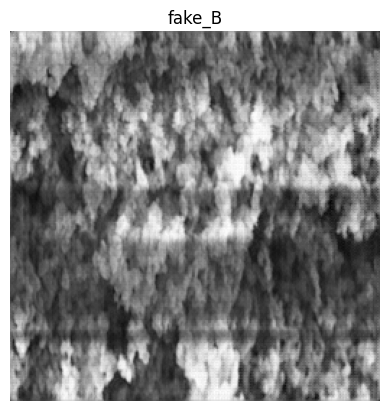

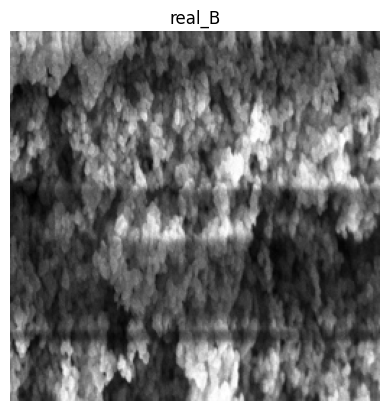

Batch 20: OrderedDict([('G_GAN', 3.0159342288970947), ('G_L1', 5.0559186935424805), ('D_real', 0.0009034321992658079), ('D_fake', 0.3480606973171234)])


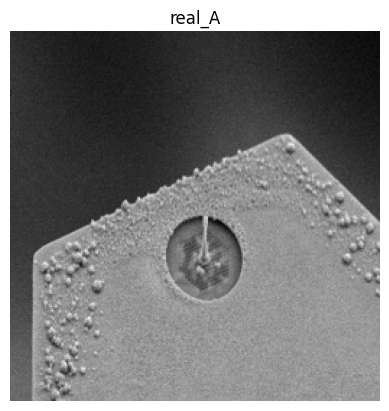

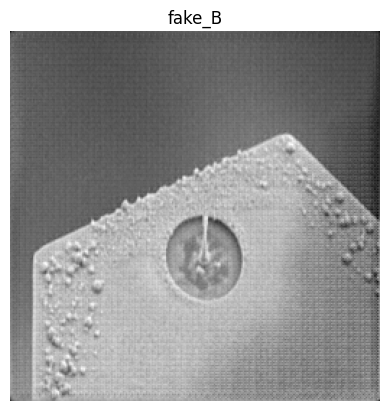

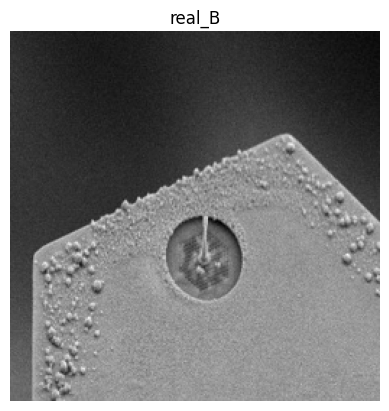

KeyboardInterrupt: 

In [52]:
p2p_model.eval()

val_loss_sum = 0.0
num_batches = 0

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(val_loader):
        p2p_model.set_input({'A': x, 'B': y, 'A_paths': '', 'B_paths': ''})
        p2p_model.test()
        losses = p2p_model.get_current_losses()
        if batch_idx <= 20:
            if (batch_idx + 1) % 10 == 0:
                print(f"Batch {batch_idx + 1}: {p2p_model.get_current_losses()}")
                visuals = p2p_model.get_current_visuals()

                for name, img in visuals.items():
                    img = img.detach().cpu()
                    if img.ndim == 4:
                        img = img[0]
                    if img.shape[0] == 1:
                        img = img.squeeze(0)
                        plt.imshow(img.numpy(), cmap='gray')
                    else:
                        plt.imshow(img.permute(1, 2, 0).numpy())
                    plt.title(name)
                    plt.axis('off')
                    plt.show()
                


In [ ]:
def noisy_sample(A):
    with Image.open(A) as img:
        img_array = np.array(img)[:, :, 0]

    noise_obj = NoiseImage()
    noisy_ip = noise_obj.new_augment_sem((img_array * 255).astype(np.uint8)).astype(np.float32) / 255.0

    out = transform_1(256)
    x = out(image = noisy_ip)["image"]
    y = out(image=img_array.astype(np.float32))["image"]

    x_noised = torch.from_numpy(x).unsqueeze(0).unsqueeze(0).float()
    y_batch = torch.from_numpy(y).unsqueeze(0).unsqueeze(0).float()
    return x_noised, y_batch

def predict_only_A(model, A, device):
    model.eval()
    with torch.no_grad():
        model.set_input({
            "A": A.unsqueeze(0).to(device),
            "B": A.unsqueeze(0).to(device),
            "A_paths": "",
            "B_paths": ""
        })
        model.test()
        return model.get_current_visuals()["fake_B"]
    

In [66]:
def tensor_to_display(img_t):
    if isinstance(img_t, torch.Tensor):
        img_t = img_t.detach().cpu().squeeze().numpy()
    else:
        img_t = np.squeeze(img_t)

    return img_t



def run_single_image_inference(ip_img, model, transform, noise_obj, device):
    x_noised, y_batch = noisy_sample(ip_img)
    fake_B = predict_only_A(model, x_noised[0], device)

    gt_vis = tensor_to_display(y_batch)
    fake_vis = tensor_to_display(fake_B)
    realA_vis = tensor_to_display(x_noised)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(gt_vis, cmap="gray")
    axes[0].set_title("Ground Truth - clean image")
    axes[0].axis("off")

    axes[1].imshow(fake_vis, cmap="gray")
    axes[1].set_title("Prediction")
    axes[1].axis("off")

    axes[2].imshow(realA_vis, cmap="gray")
    axes[2].set_title("Real A - input image")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return {
        "ground_truth": gt_vis,
        "real_A": realA_vis,
        "fake_B": fake_B,
        "x_noised": x_noised
    }


In [67]:
noise_obj = NoiseImage()

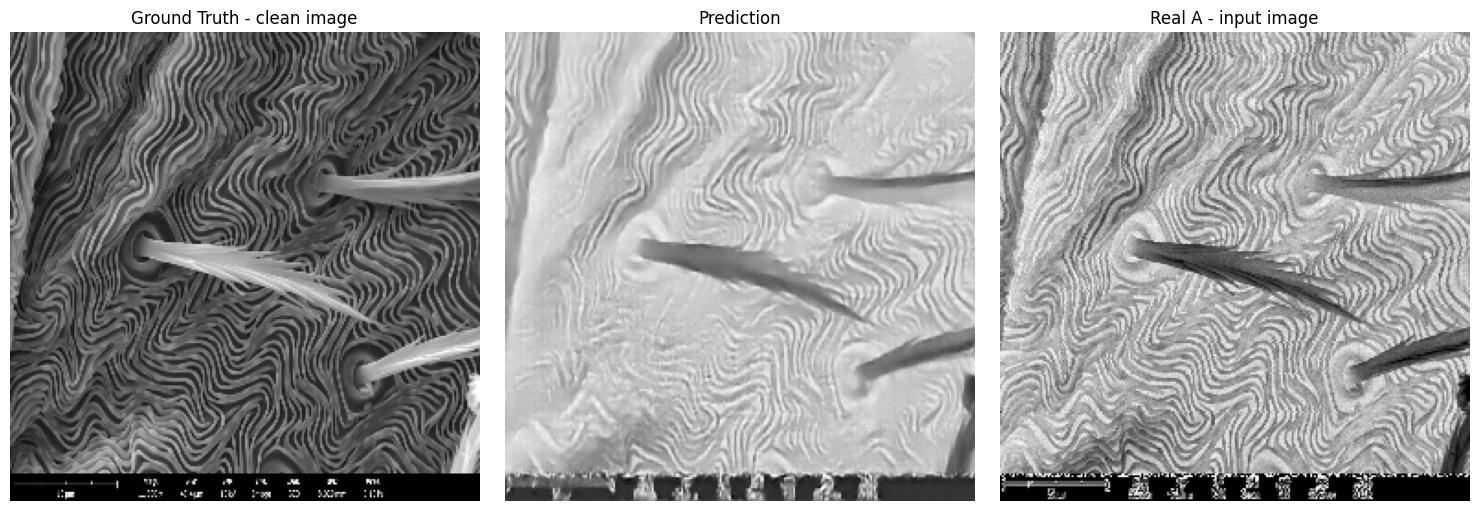

In [68]:
ip_img = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/notebooks/images/Red-Velvet-Mite-SEM-Image.jpg'

out = run_single_image_inference(
    ip_img=ip_img,
    model=p2p_model,
    transform=transform_3,
    noise_obj=noise_obj,
    device=device
)

In [8]:
p2p_model.load_networks(8)

loading the model from p2pcheckpoints/pix2pix_sem/8_net_G.pth
loading the model from p2pcheckpoints/pix2pix_sem/8_net_D.pth
